# Stage 8C.1 - Full Beam-to-Write Cockpit MVP

This notebook is an optical/energy/exposure cockpit. It does not predict material modification.

The purpose is to tune the editable source-to-sample lab chain, inspect real optical-field fluence diagnostics, and keep exposure bookkeeping visible while future material-response modules remain intentionally disabled.

## Notebook roadmap

Run the cells top to bottom:

1. **Set controls** - edit the single user-control cell below.
2. **Run the lab realism report** - stage-by-stage source-to-sample status.
3. **Acquire the real optical field** - from the repository engine (fails loudly if unavailable).
4. **Convert to fluence** - energy-scaled optical fluence (Mode B).
5. **Inspect the dashboard** - header status badge, beam-path strip, warning cards, XY / central ROI / XZ panels.
6. **Inspect the warnings** - captured-power drift, crop-edge peak, and feasibility flags.
7. **Interpret the claim boundary** - optical fluence only; material response is a future stage.

The large **DISPLAY TRUST** badge (PASS / CAUTION / FAIL) tells you at a glance whether the current optical/fluence display can be trusted.


In [1]:
# ============================================================
# FULL BEAM-TO-WRITE COCKPIT MVP - USER CONTROLS
# ============================================================

planning_mode = True
save_outputs = False
figure_dpi = 180
show_caveats = True
show_warnings = True
show_diagnostic_panels = True

# --- Simulation quality ---
engine_preset = "fast"          # fast | balanced | publication
engine_path = "ideal"           # ideal | realistic
require_real_field = True
allow_synthetic_demo_field = False

# --- Laser source ---
wavelength_nm = 1030.0
pulse_duration_fs = 260.0
repetition_rate_Hz = 25_000.0
pulse_energy_before_optics_uJ = 200.0
average_power_limit_W = 10.0
beam_radius_mm = 2.0
polarisation_state = "linear"

# --- Pre-SLM beam conditioning ---
pre_slm_transmission = 1.0
input_beam_radius_mm = 2.0
beam_ellipticity = 1.0
pointing_offset_x_um = 0.0
pointing_offset_y_um = 0.0
aperture_radius_mm = None

# --- Telescope / beam expander ---
telescope_enabled = False
telescope_magnification = 1.0
telescope_transmission = 1.0

# --- SLM1 phase / vortex ---
slm1_enabled = True
phase_profile = "vortex"
ell = 3
phase_quantisation_levels = 256
slm_pixel_pitch_um = 8.0
slm_active_width_px = None
slm_active_height_px = None
slm1_diffraction_efficiency = 0.95

# --- SLM2 / axicon / holography ---
generation_method = "holographic"    # holographic | physical
target_core_diameter_um = 3.0
target_bessel_length_um = 150.0
axicon_k_r = None
blaze_period_px = 20
slm2_diffraction_efficiency = 0.95
slm2_conjugate_mode = "preserve_vortex"
physical_axicon_enabled = False
physical_axicon_angle_deg = None

# --- First-order filtering ---
first_order_filter_enabled = True
selected_first_order_fraction = 0.73
filter_radius_px_or_lpmm = None
zero_order_leakage_fraction = 0.0

# --- Relay optics ---
relay_transmission = 0.90
relay_magnification = 1.0
relay_aberration_enabled = False

# --- Objective and pupil ---
objective_NA = 0.45
objective_transmission = 0.85
objective_effective_focal_length_mm = None
objective_pupil_diameter_mm = None
pupil_diameter_override_mm = None

# --- Sample/interface ---
material_name = "Cr:ZnSe"
refractive_index = 2.44
sample_thickness_mm = 5.0
focus_depth_um = 100.0
sample_interface_transmission = 0.95
use_fresnel_interface_estimate = False
surface_tilt_mrad = 0.0

# --- In-sample propagation / field stack ---
grid_N = None
device_downsample = None
axial_planes = None
crop_window_um = None

# --- Field/fluence display ---
selected_z_um = "target_depth"       # target_depth | optical_peak | sample_surface | custom
selected_z_mode = selected_z_um
custom_z_um = 100.0
central_roi_half_width_um = 10.0
display_scaling = "percentile"       # linear | log | percentile
display_percentile_clip = (0.5, 99.5)
fluence_normalisation_mode = "per_plane_transverse_energy"

# --- Writing plan / exposure bookkeeping ---
writing_mode = "line_x"              # static_single | static_multi | line_x | line_y | line_z | tilted_line | disabled
scan_axis = "x"
scan_speed_mm_s = 1.0
line_length_um = 500.0
effective_diameter_um = 3.0
num_static_pulses = 100
num_passes = 1
z_step_um = 0.0
tilt_angle_deg = 0.0

# --- Future physics toggles: must remain disabled in Stage 8C.1 ---
enable_material_response = False
enable_threshold_proxy = False
enable_dose_accumulation = False
enable_nonlinear_proxy = False
enable_thermal_proxy = False
enable_microscope_proxy = False
enable_calibrated_prediction = False


# --- Stage 8C.3 active lab-realism overrides ---
# These values are copied into controls after default_lab_controls(); edit them
# to perturb the diagnostic optical field while keeping material response disabled.
active_lab_realism_overrides = {
    "enable_beam_decentre": False,
    "beam_decentre_x_um": 0.0,
    "beam_decentre_y_um": 0.0,
    "enable_beam_tilt": False,
    "beam_tilt_x_mrad": 0.0,
    "beam_tilt_y_mrad": 0.0,
    "enable_beam_ellipticity": False,
    "beam_radius_x_um": 24.0,
    "beam_radius_y_um": 24.0,
    "beam_rotation_deg": 0.0,
    "enable_input_aperture": False,
    "input_aperture_radius_um": 24.0,
    "input_aperture_decentre_x_um": 0.0,
    "input_aperture_decentre_y_um": 0.0,
    "enable_slm_phase_centre_offset": False,
    "slm_phase_centre_offset_x_um": 0.0,
    "slm_phase_centre_offset_y_um": 0.0,
    "enable_vortex_centre_offset": False,
    "vortex_centre_offset_x_um": 0.0,
    "vortex_centre_offset_y_um": 0.0,
    "enable_axicon_centre_offset": False,
    "axicon_centre_offset_x_um": 0.0,
    "axicon_centre_offset_y_um": 0.0,
    "enable_physical_axicon_misalignment": False,
    "physical_axicon_apex_offset_x_um": 0.0,
    "physical_axicon_apex_offset_y_um": 0.0,
    "physical_axicon_tilt_x_mrad": 0.0,
    "physical_axicon_tilt_y_mrad": 0.0,
    "physical_axicon_angle_error_deg": 0.0,
    "enable_axicon_apex_defect": False,
    "axicon_apex_defect_radius_um": 0.0,
    "enable_slm_phase_quantisation": False,
    "slm_phase_levels": 256,
    "enable_slm_pixelation": False,
    "enable_slm_fill_factor": False,
    "slm_fill_factor": 1.0,
    "enable_slm_dead_pixels": False,
    "dead_pixel_fraction": 0.0,
    "dead_pixel_seed": 7,
    "enable_slm_phase_noise": False,
    "slm_phase_noise_rms_rad": 0.0,
    "slm_phase_noise_seed": 11,
    "enable_slm_active_area": False,
    "slm_active_width_um": 50.0,
    "slm_active_height_um": 50.0,
    "slm_active_area_decentre_x_um": 0.0,
    "slm_active_area_decentre_y_um": 0.0,
    "enable_slm_rotation": False,
    "slm_rotation_deg": 0.0,
    "enable_mask_rotation": False,
    "phase_mask_rotation_deg": 0.0,
    "enable_zero_order_leakage": False,
    "zero_order_mode": "central_gaussian",
    "enable_unwanted_order_leakage": False,
    "unwanted_order_fraction": 0.0,
    "unwanted_order_kx_shift": 0.0,
    "unwanted_order_ky_shift": 0.0,
    "enable_first_order_filter": False,
    "first_order_filter_radius_px": None,
    "enable_first_order_filter_decentre": False,
    "first_order_filter_decentre_x_px": 0.0,
    "first_order_filter_decentre_y_px": 0.0,
    "enable_first_order_filter_clipping": False,
    "first_order_filter_clipping_fraction_override": None,
    "enable_relay_magnification_error": False,
    "relay_magnification_error_fraction": 0.0,
    "enable_relay_decentre": False,
    "relay_decentre_x_um": 0.0,
    "relay_decentre_y_um": 0.0,
    "enable_relay_tilt": False,
    "relay_tilt_x_mrad": 0.0,
    "relay_tilt_y_mrad": 0.0,
    "enable_relay_aperture": False,
    "relay_aperture_radius_um": 30.0,
    "relay_aperture_decentre_x_um": 0.0,
    "relay_aperture_decentre_y_um": 0.0,
    "enable_pupil_clipping": False,
    "pupil_radius_um": 20.0,
    "pupil_decentre_x_um": 0.0,
    "pupil_decentre_y_um": 0.0,
    "pupil_fill_target_fraction": 0.8,
    "enable_zernike_aberrations": False,
    "zernike_defocus_waves": 0.0,
    "zernike_astig_0_waves": 0.0,
    "zernike_astig_45_waves": 0.0,
    "zernike_coma_x_waves": 0.0,
    "zernike_coma_y_waves": 0.0,
    "zernike_spherical_waves": 0.0,
    "zernike_trefoil_x_waves": 0.0,
    "zernike_trefoil_y_waves": 0.0,
    "enable_defocus": False,
    "focus_offset_um": 0.0,
    "enable_focus_depth_error": False,
    "focus_depth_error_um": 0.0,
    "enable_sample_tilt": False,
    "sample_tilt_x_mrad": 0.0,
    "sample_tilt_y_mrad": 0.0,
    "enable_surface_offset": False,
    "sample_surface_z_um": 0.0,
    "enable_refractive_index_error": False,
    "refractive_index_error": 0.0,
    "enable_sample_thickness_limit": False,
    "enable_interface_reflection": False,
    "enable_pulse_energy_jitter": False,
    "pulse_energy_jitter_rms_fraction": 0.0,
    "pulse_energy_jitter_seed": 23,
    "enable_repetition_rate_error": False,
    "repetition_rate_error_fraction": 0.0,
    "enable_pulse_duration_error": False,
    "pulse_duration_error_fraction": 0.0,
    "enable_average_power_limit": True,
    "enable_pointing_jitter": False,
    "pointing_jitter_rms_urad": 0.0,
    "pointing_jitter_seed": 31,
    "enable_stage_position_jitter": False,
    "stage_jitter_x_um": 0.0,
    "stage_jitter_y_um": 0.0,
    "stage_jitter_z_um": 0.0,
    "stage_jitter_seed": 37,
    "enable_focus_drift": False,
    "focus_drift_um_per_min": 0.0,
    "enable_camera_crop": False,
    "camera_crop_width_um": 20.0,
    "camera_crop_height_um": 20.0,
    "camera_crop_centre_x_um": 0.0,
    "camera_crop_centre_y_um": 0.0,
    "enable_detector_noise": False,
    "detector_noise_fraction": 0.0,
    "detector_noise_seed": 41,
    "enable_display_autoscale": True,
    "display_autoscale": True,
}


## 1. Purpose and claim boundary

This notebook is an optical/energy/exposure cockpit. It does not predict material modification. It scales real optical-field intensity arrays to optical fluence, reports energy throughput, and performs exposure bookkeeping only.

In [2]:
# Guard rails for saving, demo fields, and future physics toggles.
if save_outputs and not show_caveats:
    raise ValueError("Cannot save Stage 8C.1 outputs with show_caveats=False.")

future_flags = {
    "enable_material_response": enable_material_response,
    "enable_threshold_proxy": enable_threshold_proxy,
    "enable_dose_accumulation": enable_dose_accumulation,
    "enable_nonlinear_proxy": enable_nonlinear_proxy,
    "enable_thermal_proxy": enable_thermal_proxy,
    "enable_microscope_proxy": enable_microscope_proxy,
    "enable_calibrated_prediction": enable_calibrated_prediction,
}
if any(future_flags.values()):
    enabled = [name for name, value in future_flags.items() if value]
    raise NotImplementedError(f"Stage 8C.1 does not implement future physics toggles: {enabled}")
if allow_synthetic_demo_field and save_outputs:
    raise ValueError("unit_test_or_demo_only fields cannot be saved as governed outputs.")

CAVEAT_TEXT = (
    "This is an optical/energy/exposure cockpit. It does not model absorption, "
    "material modification, ablation, cracks, voids, waveguides, nonlinear propagation, "
    "or thermal accumulation. Energy-scaled fluence is optical fluence only."
)
if show_caveats:
    print(CAVEAT_TEXT)


This is an optical/energy/exposure cockpit. It does not model absorption, material modification, ablation, cracks, voids, waveguides, nonlinear propagation, or thermal accumulation. Energy-scaled fluence is optical fluence only.


In [3]:
# ============================================================
# RUNTIME CHECK + AUTORELOAD + INLINE BACKEND
# Prevents two failure modes:
#   1. stale import / wrong path -> notebook renders the OLD dashboard
#   2. matplotlib.use("Agg") in the modules -> display(fig) shows NO image inline
# ============================================================
import os
import sys
import inspect
from pathlib import Path

# Enable autoreload so edits to vbb_study are picked up without a manual kernel restart.
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("load_ext", "autoreload")
        _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Make sure the local Publication_Study package wins on sys.path.
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "bessel_twin_core.py").is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

# Import the digital-twin modules first. They call matplotlib.use("Agg") at import,
# so we re-enable the inline backend AFTERWARDS to guarantee figures render in-notebook.
import vbb_study
import vbb_study.digital_twin.cockpit_dashboard as cd
try:
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("Python    :", sys.executable)
print("CWD       :", os.getcwd())
print("vbb_study :", Path(vbb_study.__file__).resolve())
print("cockpit   :", Path(cd.__file__).resolve())
print("has compute_overall_status :", hasattr(cd, "compute_overall_status"))
print("has build_beam_path_strip  :", hasattr(cd, "build_beam_path_strip"))
print("dashboard is Stage 8C.2    :", "DISPLAY TRUST" in inspect.getsource(cd))

# Fail loudly if a stale module is loaded so we never silently render the old dashboard.
assert hasattr(cd, "compute_overall_status"), "Stale cockpit_dashboard import - restart the kernel."
assert "DISPLAY TRUST" in inspect.getsource(cd), "Old dashboard loaded - restart kernel / check path."

Python    : C:\PhD\.venv2\Scripts\python.exe
CWD       : C:\PhD\Code\Publication_Study\notebooks\digital_twin
vbb_study : C:\PhD\Code\Publication_Study\vbb_study\__init__.py
cockpit   : C:\PhD\Code\Publication_Study\vbb_study\digital_twin\cockpit_dashboard.py
has compute_overall_status : True
has build_beam_path_strip  : True
dashboard is Stage 8C.2    : True


In [4]:
from pathlib import Path
import sys
import numpy as np

_root = Path.cwd()
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "bessel_twin_core.py").is_file():
        _root = _candidate
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from vbb_study.digital_twin.field_coupling import (
    MissingOpticalFieldError,
    extract_plane_from_surfacefield,
    extract_stack_from_surfacefield,
    plane_from_arrays,
)
from vbb_study.digital_twin.field_fluence import scale_plane_to_fluence, scale_stack_to_fluence
from vbb_study.digital_twin.lab_perturbations import (
    apply_lab_perturbations_to_stack,
    classification_rows_for_controls,
    physical_placement_rows_for_controls,
)
from vbb_study.digital_twin.active_realism_metrics import (
    build_stage8c3_sensitivity_scenarios,
    compute_misalignment_sensitivity_sweep,
    compute_degradation_metrics,
    metric_delta_table,
    plot_baseline_vs_perturbed_comparison,
    plot_misalignment_sensitivity_sweep,
)
from vbb_study.digital_twin.lab_realism_controls import (
    default_lab_controls,
    build_energy_ledger_from_controls,
    build_exposure_summary_from_controls,
    build_lab_realism_report,
)
from vbb_study.digital_twin.cockpit_dashboard import (
    compute_peak_location_diagnostics,
    build_warning_flags,
    plot_integrated_cockpit_dashboard,
    make_interpretation_text,
)


## 2. User controls

All editable controls are in the first code cell.

In [5]:
control_names = [
    "planning_mode", "save_outputs", "figure_dpi", "show_caveats", "show_warnings", "show_diagnostic_panels",
    "engine_preset", "engine_path", "require_real_field", "allow_synthetic_demo_field",
    "wavelength_nm", "pulse_duration_fs", "repetition_rate_Hz", "pulse_energy_before_optics_uJ", "average_power_limit_W", "beam_radius_mm", "polarisation_state",
    "pre_slm_transmission", "input_beam_radius_mm", "beam_ellipticity", "pointing_offset_x_um", "pointing_offset_y_um", "aperture_radius_mm",
    "telescope_enabled", "telescope_magnification", "telescope_transmission",
    "slm1_enabled", "phase_profile", "ell", "phase_quantisation_levels", "slm_pixel_pitch_um", "slm_active_width_px", "slm_active_height_px", "slm1_diffraction_efficiency",
    "generation_method", "target_core_diameter_um", "target_bessel_length_um", "axicon_k_r", "blaze_period_px", "slm2_diffraction_efficiency", "slm2_conjugate_mode", "physical_axicon_enabled", "physical_axicon_angle_deg",
    "first_order_filter_enabled", "selected_first_order_fraction", "filter_radius_px_or_lpmm", "zero_order_leakage_fraction",
    "relay_transmission", "relay_magnification", "relay_aberration_enabled",
    "objective_NA", "objective_transmission", "objective_effective_focal_length_mm", "objective_pupil_diameter_mm", "pupil_diameter_override_mm",
    "material_name", "refractive_index", "sample_thickness_mm", "focus_depth_um", "sample_interface_transmission", "use_fresnel_interface_estimate", "surface_tilt_mrad",
    "grid_N", "device_downsample", "axial_planes", "crop_window_um",
    "selected_z_um", "selected_z_mode", "custom_z_um", "central_roi_half_width_um", "display_scaling", "display_percentile_clip", "fluence_normalisation_mode",
    "writing_mode", "scan_axis", "scan_speed_mm_s", "line_length_um", "effective_diameter_um", "num_static_pulses", "num_passes", "z_step_um", "tilt_angle_deg",
    "enable_material_response", "enable_threshold_proxy", "enable_dose_accumulation", "enable_nonlinear_proxy", "enable_thermal_proxy", "enable_microscope_proxy", "enable_calibrated_prediction",
]
controls = default_lab_controls()
controls.update({name: globals()[name] for name in control_names})
controls.update(active_lab_realism_overrides)


## 3. Stage-by-stage lab realism report

The `LabRealismReport` is the central source-to-sample table: every stage reports editable inputs, computed outputs, warnings, missing metrics, and handoff.

In [6]:
ledger = build_energy_ledger_from_controls(controls)
exposure_summary = build_exposure_summary_from_controls(
    controls,
    pulse_energy_at_sample_uJ=ledger.energy_at_sample_uJ,
    repetition_rate_Hz=repetition_rate_Hz,
)
lab_report = build_lab_realism_report(controls, energy_ledger=ledger, exposure_summary=exposure_summary)
lab_report.to_dataframe()


,stage_name,enabled,key_inputs,key_outputs,model_status,status_level,warnings,missing_metrics,control_classifications,affected_outputs,handoff_to_next_stage
0,laser_source,True,wavelength_nm=1030; pulse_duration_fs=260; rep...,average_power_before_optics_W=5; power_limit_s...,energy_accounting_prediction,pass,,,wavelength_nm:metadata_only; pulse_duration_fs...,"metadata, fluence, energy_ledger, exposure_boo...",pulse energy and source metadata to pre-SLM co...
1,pre_slm_beam_conditioning,True,pre_slm_transmission=1; input_beam_radius_mm=2...,energy_after_pre_slm_uJ=200; beam_radius_at_sl...,energy_accounting_prediction,missing,,aperture clipping not available from current e...,pre_slm_transmission:energy_active; input_beam...,"energy_ledger, fluence, metadata, warnings, fi...",conditioned beam radius and energy to telescop...
2,telescope_or_beam_expander,False,telescope_enabled=False; telescope_magnificati...,beam_radius_after_telescope_mm=2; energy_after...,energy_accounting_prediction,diagnostic_only,,,telescope_enabled:geometry_active; telescope_m...,"metadata, warnings, energy_ledger, fluence",beam radius and energy to SLM1
3,slm1_phase,True,slm1_enabled=True; phase_profile=vortex; ell=3...,slm_sampling_status=active area not available ...,optical_prediction,pass,,SLM active area not available from current engine,slm1_enabled:metadata_only; phase_profile:meta...,"metadata, warnings, amplitude, field, fluence,...",vortex/phase state and energy to SLM2 route
4,slm2_phase_or_axicon,True,generation_method=holographic; axicon_k_r=None...,route_status=holographic route; measured_topol...,optical_prediction,pass,,measured topological winding not available fro...,generation_method:metadata_only; axicon_k_r:me...,"metadata, warnings, energy_ledger, fluence, ph...",routed diffracted field to first-order filtering
5,first_order_filter,True,first_order_filter_enabled=True; selected_firs...,carrier_frequency_lpmm=not available from curr...,optical_prediction,pass,,carrier/cone frequency not available from curr...,first_order_filter_enabled:energy_active; sele...,"energy_ledger, warnings, fluence, field, ampli...",selected diffraction order to relay optics
6,relay_optics,True,relay_transmission=0.9; relay_magnification=1;...,energy_after_relay_uJ=computed in energy ledge...,energy_accounting_prediction,pass,,,relay_transmission:energy_active; relay_magnif...,"energy_ledger, fluence, pupil, metadata, warni...",relayed beam to objective pupil
7,objective_and_pupil,True,objective_NA=0.45; objective_transmission=0.85...,pupil_radius_mm=not available from current eng...,optical_prediction,missing,,objective pupil diameter not available from cu...,objective_NA:geometry_active; objective_transm...,"pupil, metadata, warnings, energy_ledger, flue...",focused field to sample interface
8,sample_interface,True,material_name=Cr:ZnSe; refractive_index=2.44; ...,fresnel_normal_incidence_transmission=0.8248; ...,energy_accounting_prediction,pass,,,material_name:geometry_active; refractive_inde...,"sample_geometry, energy_ledger, warnings, flue...",sample-entered optical field to propagation stack
9,in_sample_propagation,True,engine_preset=fast; engine_path=ideal; grid_N=...,field_source_status=not available from current...,optical_prediction,fail,real field is required by controls,real optical field summary not available from ...,engine_preset:diagnostic_active; engine_path:d...,"field, warnings, metadata",real optical intensity stack to fluence scaling


## Active Lab-Realism Controls

Every editable control is classified as `energy_active`, `geometry_active`, `diagnostic_active`, `warning_only`, `metadata_only`, or `future_not_implemented`, with declared affected outputs, implementation status, physical placement, and actual Stage 8C.3 implementation stage. `physics_active` remains a reserved class for future engine-level pre-propagation coupling, but this post-engine diagnostic layer does not use it for stack/image transforms.

In the current scalar optical model, direct Poynting-vector editing is not a primitive active input. Beam direction changes are represented by input beam tilt / angular-spectrum phase ramp. Polarisation and true vectorial energy-flow effects require a vector engine and are metadata-only unless the vector path is active.

The physical-placement audit distinguishes where a perturbation belongs optically from how Stage 8C.3 applies it today. A control can belong at the input field, SLM phase-mask, SLM amplitude/active-area, Fourier plane, relay plane, or objective pupil plane while still being marked `post-propagation diagnostic only` in this MVP.


In [7]:
active_control_columns = [
    "control",
    "value",
    "enabled",
    "classification",
    "affects",
    "implemented",
    "downstream_response_expected",
    "physical_placement",
    "implementation_stage",
    "placement_note",
]
active_control_rows = classification_rows_for_controls(controls)
try:
    import pandas as pd
    active_control_table = pd.DataFrame(active_control_rows)[active_control_columns]
    display(active_control_table)
except Exception:
    active_control_table = active_control_rows
    display(active_control_table)


,control,value,enabled,classification,affects,implemented,downstream_response_expected,physical_placement,implementation_stage,placement_note
0,planning_mode,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
1,save_outputs,False,False,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
2,figure_dpi,180,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
3,show_caveats,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
4,show_warnings,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
...,...,...,...,...,...,...,...,...,...,...
215,enable_detector_noise,False,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
216,detector_noise_fraction,0.0,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
217,detector_noise_seed,41,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
218,enable_display_autoscale,True,True,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,autoscale is display-only


## 4. Experiment request summary

In [8]:
experiment_request = {
    "laser": f"{wavelength_nm} nm, {pulse_duration_fs} fs, {repetition_rate_Hz} Hz",
    "route": f"{generation_method} VBB, ell={ell}",
    "slm_settings": f"SLM1 {phase_profile}; SLM2 {slm2_conjugate_mode}; blaze={blaze_period_px} px",
    "optical_chain": f"first order={selected_first_order_fraction}, relay={relay_transmission}, objective={objective_transmission}",
    "sample": f"{material_name}, n={refractive_index}, focus depth={focus_depth_um} um",
    "writing_plan": f"{writing_mode}, {scan_speed_mm_s} mm/s, {line_length_um} um",
    "selected_visual_plane": selected_z_um,
}
experiment_request


{'laser': '1030.0 nm, 260.0 fs, 25000.0 Hz',
 'route': 'holographic VBB, ell=3',
 'slm_settings': 'SLM1 vortex; SLM2 preserve_vortex; blaze=20 px',
 'optical_chain': 'first order=0.73, relay=0.9, objective=0.85',
 'sample': 'Cr:ZnSe, n=2.44, focus depth=100.0 um',
 'writing_plan': 'line_x, 1.0 mm/s, 500.0 um',
 'selected_visual_plane': 'target_depth'}

## 5. Energy ledger

In [9]:
print(f"Pulse energy before optics: {pulse_energy_before_optics_uJ:.4g} uJ")
print(f"Energy at sample: {ledger.energy_at_sample_uJ:.4g} uJ")
print(f"Average power at sample: {ledger.average_power_at_sample_W:.4g} W")
print(f"Cumulative throughput: {ledger.total_throughput_fraction:.2%}")
for row in ledger.rows:
    print(f"{row.component_name:30s} {row.energy_in_uJ:9.4g} -> {row.energy_out_uJ:9.4g} uJ  frac={row.fraction_this_component:.3g}")
for warning in ledger.ledger_warnings:
    print("WARNING:", warning)


Pulse energy before optics: 200 uJ
Energy at sample: 95.76 uJ
Average power at sample: 2.394 W
Cumulative throughput: 47.88%
pre_slm_beam_conditioning            200 ->       200 uJ  frac=1
telescope_or_beam_expander           200 ->       200 uJ  frac=1
slm1_phase                           200 ->       190 uJ  frac=0.95
slm2_phase_or_axicon                 190 ->     180.5 uJ  frac=0.95
first_order_filter                 180.5 ->     131.8 uJ  frac=0.73
relay_optics                       131.8 ->     118.6 uJ  frac=0.9
objective_and_pupil                118.6 ->     100.8 uJ  frac=0.85
sample_interface                   100.8 ->     95.76 uJ  frac=0.95


## 6. Lab realism / hardware feasibility panel

Energy/power limit, first-order geometry, pupil fill/clipping, SLM sampling/downsampling, route validity, crop-window/captured-power drift, peak near edge, pulse overlap, and material-response availability are all shown as pass/caution/fail/missing/disabled states.

In [10]:
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary)
warning_flags


{'captured_power_drift': {'status': 'pass',
  'message': 'raw captured-power drift acceptable'},
 'crop_edge_peak': {'status': 'pass',
  'message': 'global peak is not near crop edge'},
 'first_order_geometry': {'status': 'pass',
  'message': 'first-order geometry valid'},
 'pupil_clipping': {'status': 'pass',
  'message': 'pupil clipping not detected'},
 'power_limit': {'status': 'pass',
  'message': 'average power within configured limit'},
 'pulse_overlap': {'status': 'pass',
  'message': 'pulse spacing supports continuous scan bookkeeping'}}

## 7. Real optical field acquisition

Use the real repository engine. If no governed optical field is available and `require_real_field=True`, fail loudly. A labelled `unit_test_or_demo_only` branch exists only for local notebook wiring checks and refuses saving.

In [11]:
surface_field = None
volume = None
field_source_status = "not loaded"

try:
    import bessel_twin_core as bt
    engine_result = bt.run_case(preset=engine_preset, path=engine_path, case_id="stage8c1_integrated_cockpit")
    surface_field = engine_result.get("surface_field")
    volume = engine_result.get("volume")
    field_source_status = "real_optical_field"
except Exception as exc:
    field_source_status = f"engine unavailable: {exc}"
    print(field_source_status)

if volume is None and require_real_field and not allow_synthetic_demo_field:
    raise MissingOpticalFieldError("No real optical volume available; refusing to fabricate a production field.")

if volume is None and allow_synthetic_demo_field:
    save_outputs = False
    print("unit_test_or_demo_only: synthetic demonstration field is labelled and cannot be saved.")
    n = 64
    z_demo = np.linspace(0.0, 150.0, 5)
    x_demo = (np.arange(n) - (n - 1) / 2.0) * 0.5
    X, Y = np.meshgrid(x_demo, x_demo, indexing="xy")
    stack_demo = []
    for zval in z_demo:
        R = np.hypot(X, Y)
        stack_demo.append(np.exp(-(R ** 2) / (2 * 3.0 ** 2)) * (1.0 + 0.1 * zval / max(z_demo)))
    volume = {"intensity_stack": np.asarray(stack_demo), "z": z_demo * 1e-6, "crop_grid": {"x": x_demo * 1e-6, "y": x_demo * 1e-6}}

stack = extract_stack_from_surfacefield(volume)
plane = extract_plane_from_surfacefield(surface_field, preferred_z_um=0.0) if surface_field is not None else None
print("field_source_status:", field_source_status)
print("stack:", stack.intensity_zyx.shape, "dx_um", stack.dx_um, "dy_um", stack.dy_um)


field_source_status: real_optical_field
stack: (41, 192, 192) dx_um 0.25 dy_um 0.25


## 8. Field-to-fluence scaling

This section reports selected plane, central ROI peak, target-depth peak, sample-surface peak, peak intensity estimate, propagation/crop captured-power drift, global peak diagnostics, and edge/corner peak warning.

In [12]:
fluence_stack = scale_stack_to_fluence(stack, ledger.energy_at_sample_uJ)
fluence_plane = scale_plane_to_fluence(plane, ledger.energy_at_sample_uJ) if plane is not None else None
diagnostics = compute_peak_location_diagnostics(
    stack,
    fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    selected_z_mode=selected_z_mode,
    custom_z_um=custom_z_um,
    pulse_duration_fs=pulse_duration_fs,
)
field_summary = {
    "source_status": stack.source_status,
    "dx_um": stack.dx_um,
    "dy_um": stack.dy_um,
    "propagation_energy_drift_fraction": fluence_stack.propagation_energy_drift_fraction,
}
lab_report = build_lab_realism_report(
    controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    field_summary=field_summary,
    diagnostics=diagnostics,
)
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary, diagnostics=diagnostics)
diagnostics


{'global_peak_value': 160.0045310344464,
 'global_peak_x_um': -23.874999999999996,
 'global_peak_y_um': -23.874999999999996,
 'global_peak_z_um': -102.99987874555738,
 'global_peak_index_zyx': (0, 0, 0),
 'global_peak_distance_to_boundary_px': 0,
 'global_peak_near_boundary': True,
 'central_roi_peak_value': 94.58366495104889,
 'central_roi_peak_x_um': 0.125,
 'central_roi_peak_y_um': -2.625,
 'central_roi_peak_z_um': 65.7501212544426,
 'central_roi_peak_index_zyx': (18, 85, 96),
 'central_roi_peak_by_z_j_cm2': array([2.35506212e-01, 1.04616773e-01, 3.91371672e-02, 2.06217036e-02,
        3.98030494e-02, 6.87743870e-02, 2.96272375e-01, 1.66129768e+00,
        6.22294790e+00, 6.25701753e+00, 6.57561082e+00, 9.04899234e+00,
        3.16880298e+01, 5.00317037e+01, 6.63789467e+01, 7.89254376e+01,
        8.75535629e+01, 9.27445361e+01, 9.45836650e+01, 9.36850473e+01,
        9.01664713e+01, 8.52055400e+01, 7.90131991e+01, 7.21162862e+01,
        6.50131785e+01, 5.86332554e+01, 5.24526577e+

## Baseline vs Perturbed Misalignment Sanity Check

This diagnostic keeps identical axes and identical colour scales between baseline and perturbed maps so active-control degradation cannot be hidden by autoscaling. The demo perturbation is optical/fluence only and keeps material response disabled.


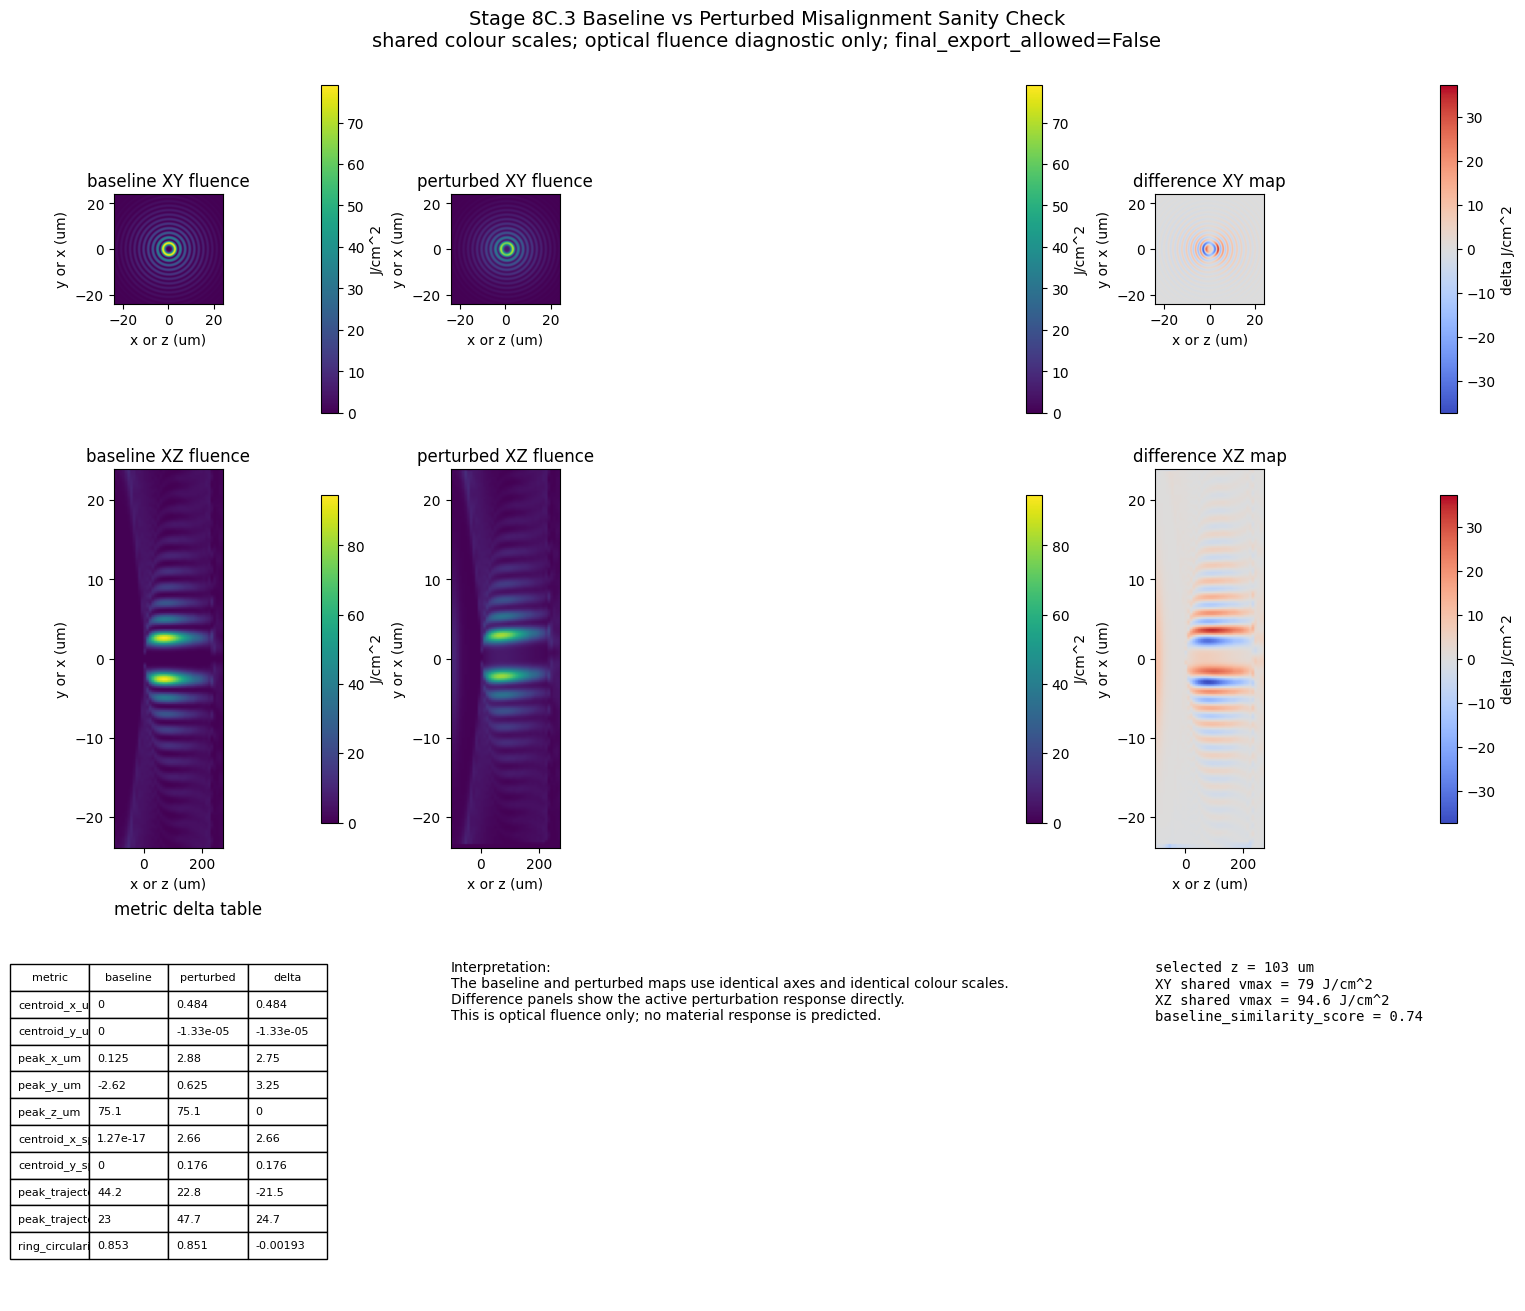

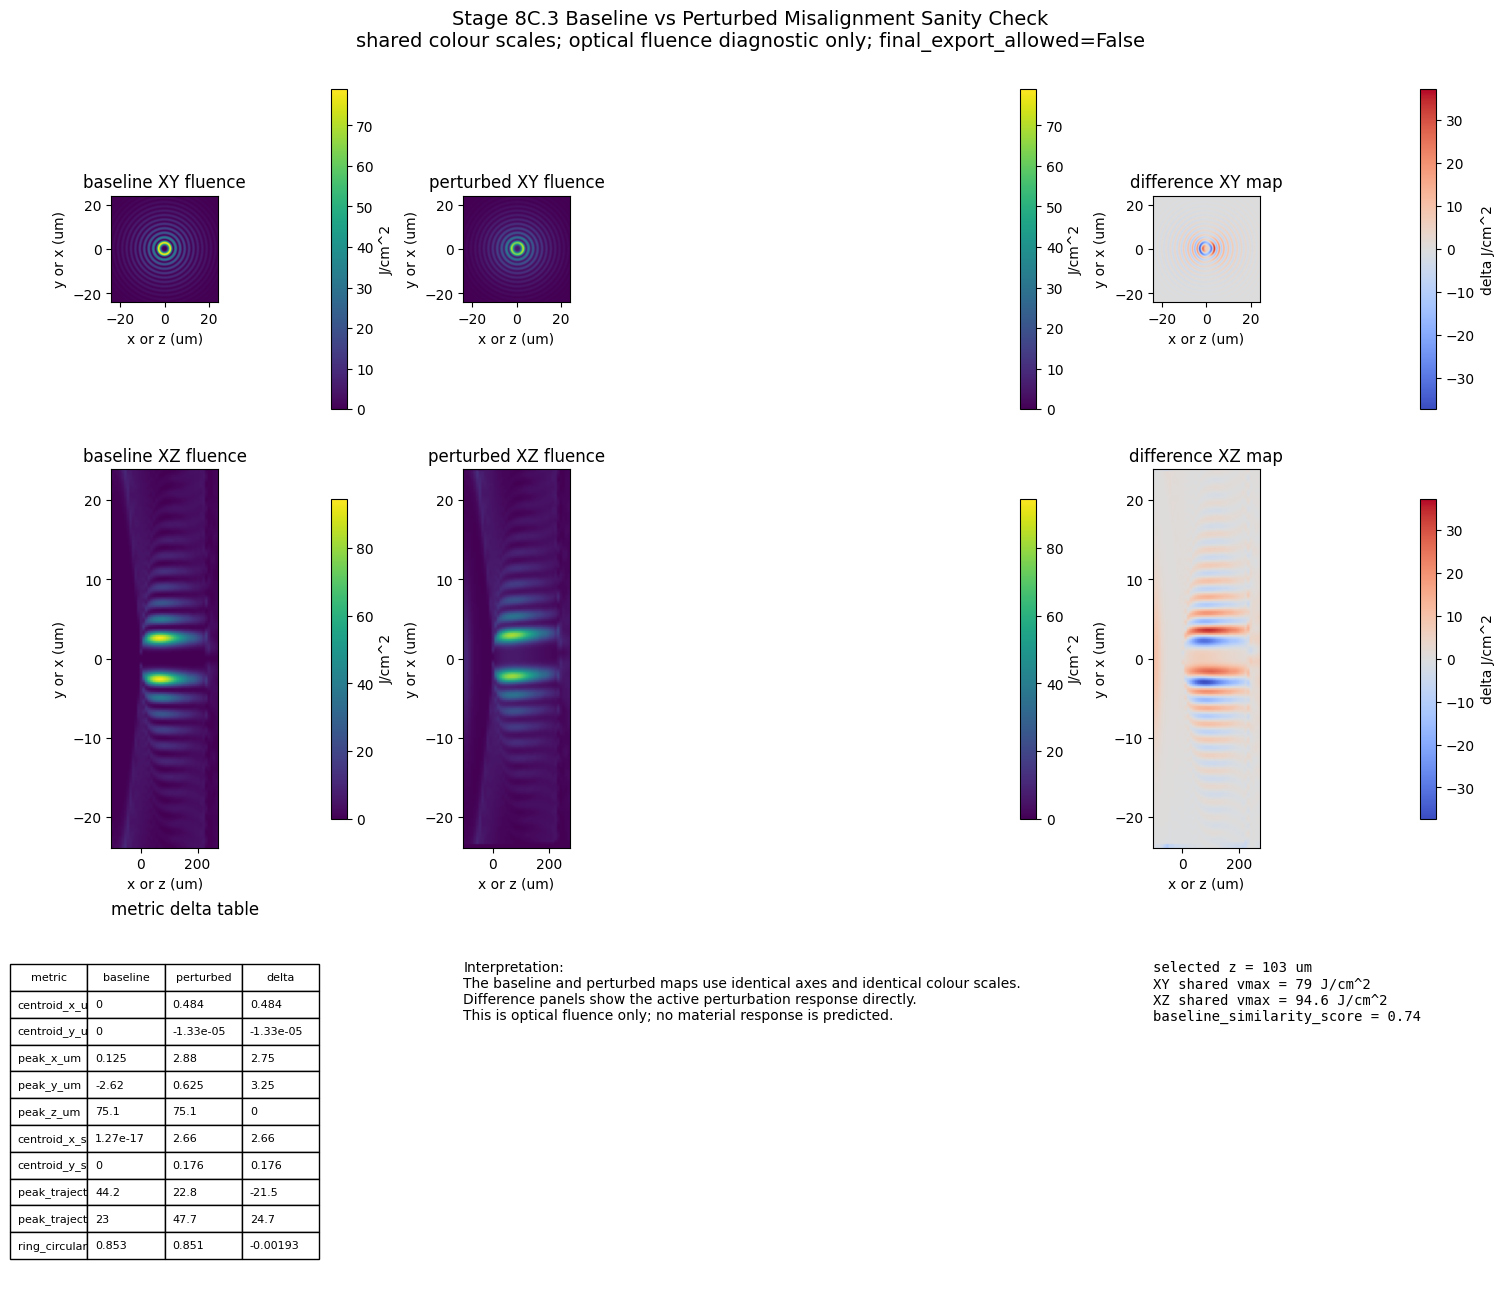

,metric,baseline,perturbed,delta
0,centroid_x_um,0.000000e+00,0.605783,0.605783
1,centroid_y_um,0.000000e+00,-0.000010,-0.000010
2,peak_x_um,1.250000e-01,2.875000,2.750000
3,peak_y_um,-2.625000e+00,0.625000,3.250000
4,peak_z_um,7.512512e+01,75.125121,0.000000
5,centroid_x_span_um,1.274032e-17,2.663604,2.663604
6,centroid_y_span_um,0.000000e+00,0.176445,0.176445
7,peak_trajectory_x_span_um,4.425000e+01,22.750000,-21.500000
8,peak_trajectory_y_span_um,2.300000e+01,47.750000,24.750000
9,ring_circularity_score,8.562252e-01,0.846547,-0.009679


In [13]:
import matplotlib.pyplot as plt

demo_perturbation_controls = dict(controls)
demo_perturbation_controls.update({
    "enable_vortex_centre_offset": True,
    "vortex_centre_offset_x_um": 4.0,
    "enable_beam_tilt": True,
    "beam_tilt_x_mrad": 2.0,
    "enable_zernike_aberrations": True,
    "zernike_coma_x_waves": 0.15,
    "enable_zero_order_leakage": True,
    "zero_order_leakage_fraction": 0.05,
})

perturbation_result = apply_lab_perturbations_to_stack(stack, demo_perturbation_controls)
perturbed_stack = perturbation_result.perturbed_stack
perturbed_fluence_stack = scale_stack_to_fluence(perturbed_stack, ledger.energy_at_sample_uJ)

baseline_degradation_metrics = compute_degradation_metrics(
    stack,
    fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
)
perturbed_degradation_metrics = compute_degradation_metrics(
    perturbed_stack,
    perturbed_fluence_stack,
    baseline_stack=stack,
    baseline_fluence_result=fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    perturbation_metadata=perturbation_result.metadata,
)
metric_delta_rows = metric_delta_table(baseline_degradation_metrics, perturbed_degradation_metrics)
warning_flags = build_warning_flags(
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    diagnostics=diagnostics,
    perturbation_result=perturbation_result,
)

comparison_output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c3_baseline_vs_perturbed_preview.png"
comparison_fig = plot_baseline_vs_perturbed_comparison(
    stack,
    perturbed_stack,
    fluence_stack,
    perturbed_fluence_stack,
    selected_plane_index=diagnostics["selected_plane_index"],
    output_path=comparison_output_path if save_outputs and stack.source_status != "unit_test_or_demo_only" else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
)
display(comparison_fig)
plt.show()
plt.close(comparison_fig)

try:
    import pandas as pd
    display(pd.DataFrame(metric_delta_rows))
except Exception:
    display(metric_delta_rows)


## Stage 8C.3C - Translation versus Genuine Degradation

Stage 8C.3C repairs the sensitivity sweep so global translation is not mistaken for shape degradation. Co-shifting vortex and axicon can be translation-dominated: unregistered similarity may drop, but registered similarity can recover once the centroid is recentered. That case is reported as translation/steering, not as a badly degraded beam.

The replacement scenarios separate relative vortex/axicon misregistration, input beam decentre with finite SLM aperture, beam tilt with finite pupil, objective pupil decentre/clipping, low-order aberrations, zero-order leakage, and a combined diagnostic stress test. All outputs remain optical/fluence diagnostics only; material response is disabled.


,control,enabled,classification,physical_placement,implementation_stage,implemented,placement_note
0,enable_beam_tilt,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam tilt belongs to input complex-field phase...
1,beam_tilt_x_mrad,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam tilt belongs to input complex-field phase...
2,enable_beam_decentre,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam decentre belongs to input amplitude/field...
3,beam_decentre_x_um,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam decentre belongs to input amplitude/field...
4,enable_vortex_centre_offset,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,vortex centre offset belongs in vortex phase-m...
5,vortex_centre_offset_x_um,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,vortex centre offset belongs in vortex phase-m...
6,enable_axicon_centre_offset,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,axicon centre offset belongs in axicon phase-m...
7,axicon_centre_offset_x_um,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,axicon centre offset belongs in axicon phase-m...
8,enable_slm_active_area,True,diagnostic_active,SLM amplitude/active-area stage,post-propagation diagnostic only,True,finite SLM active area belongs at the SLM aper...
9,slm_active_width_um,True,diagnostic_active,SLM amplitude/active-area stage,post-propagation diagnostic only,True,finite SLM active area belongs at the SLM ampl...


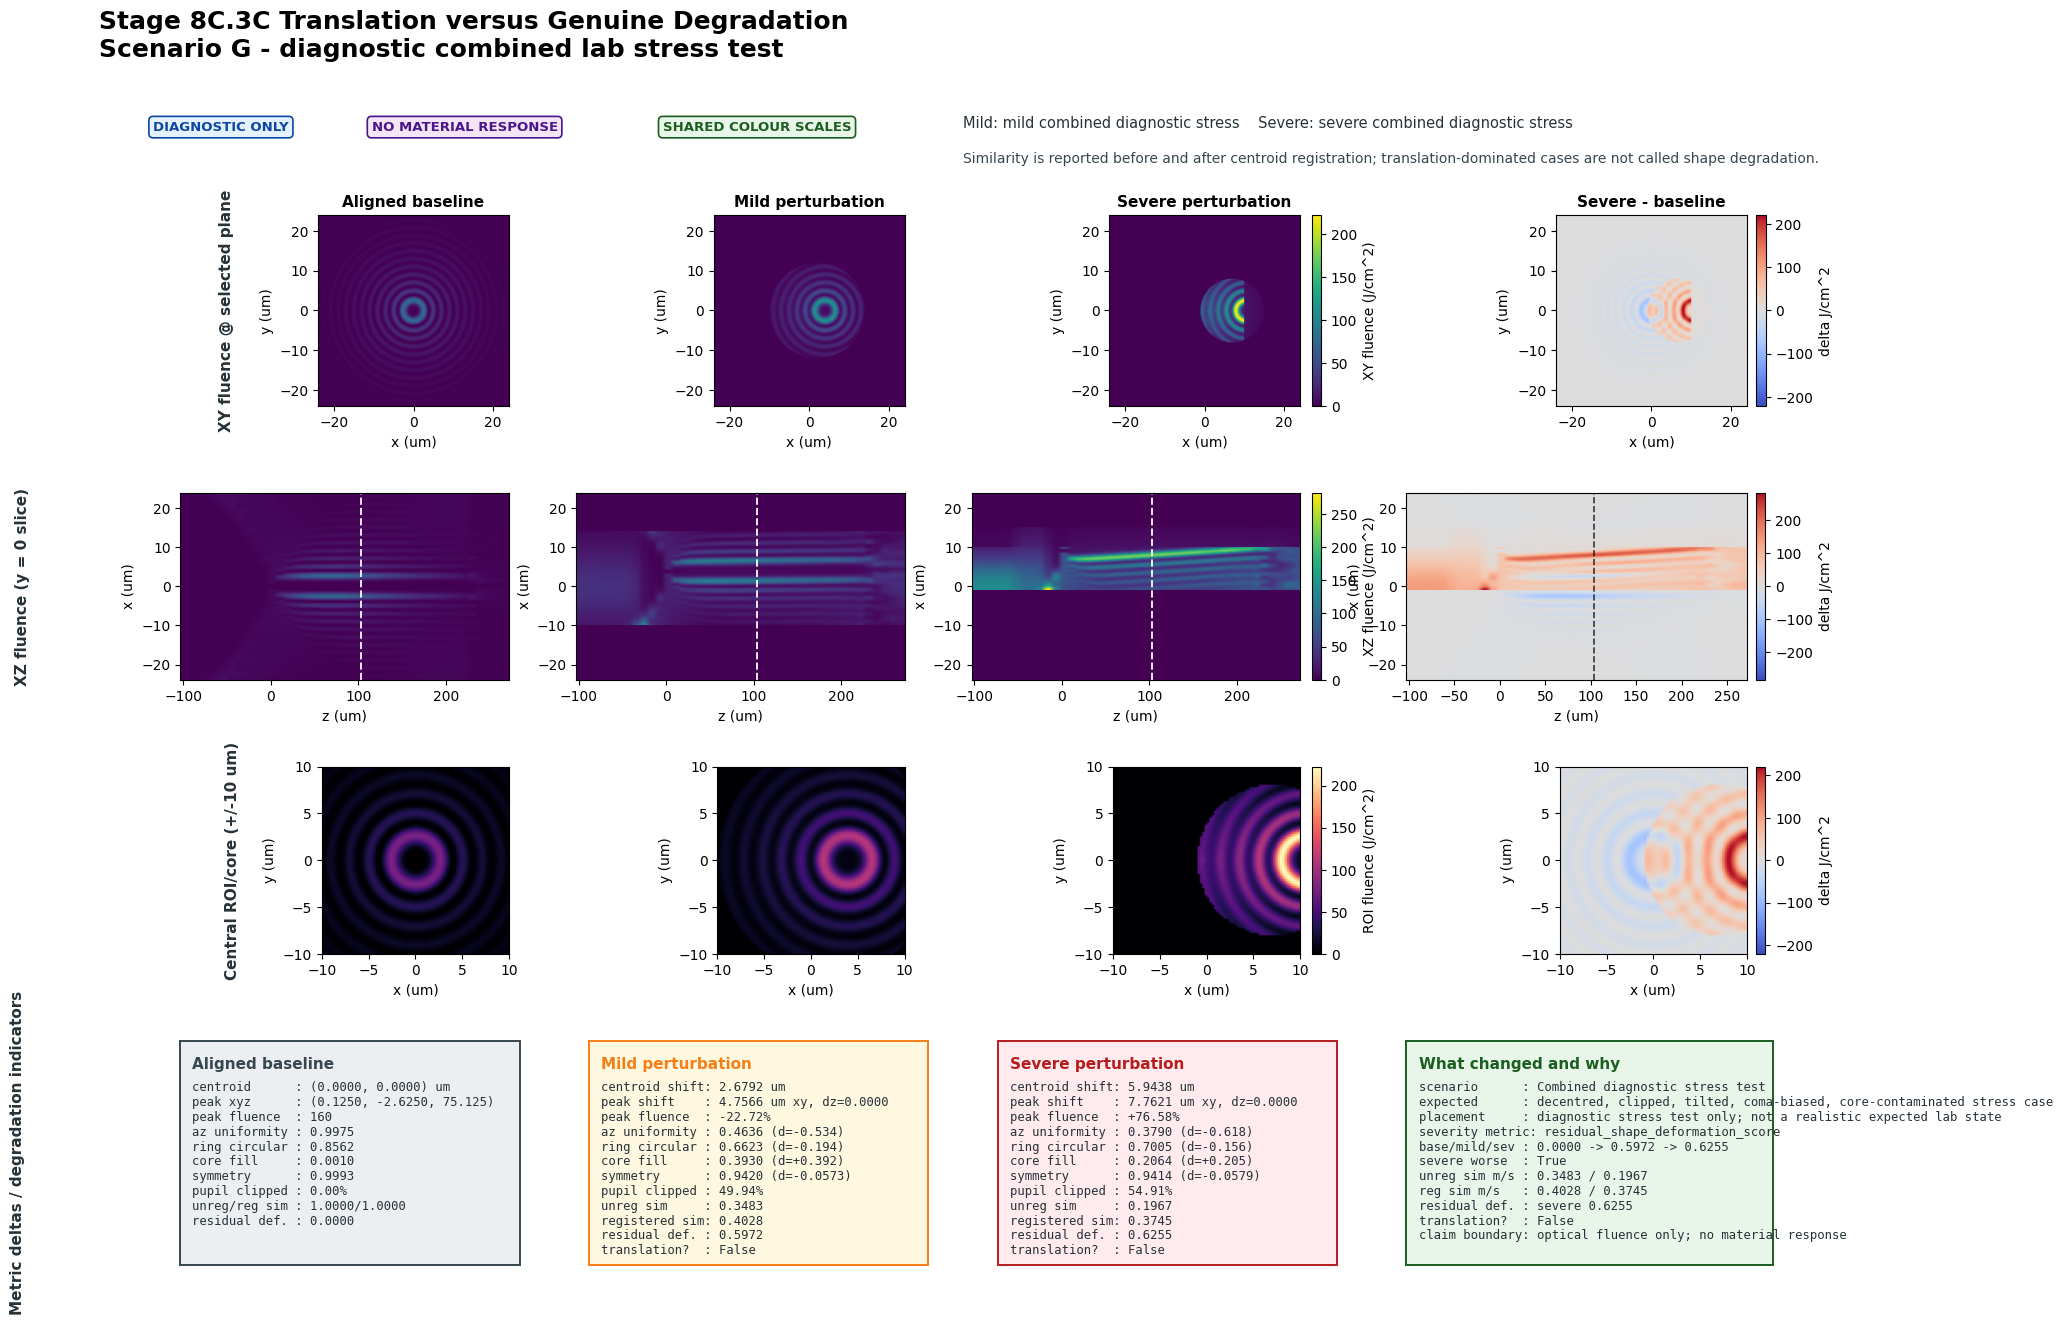

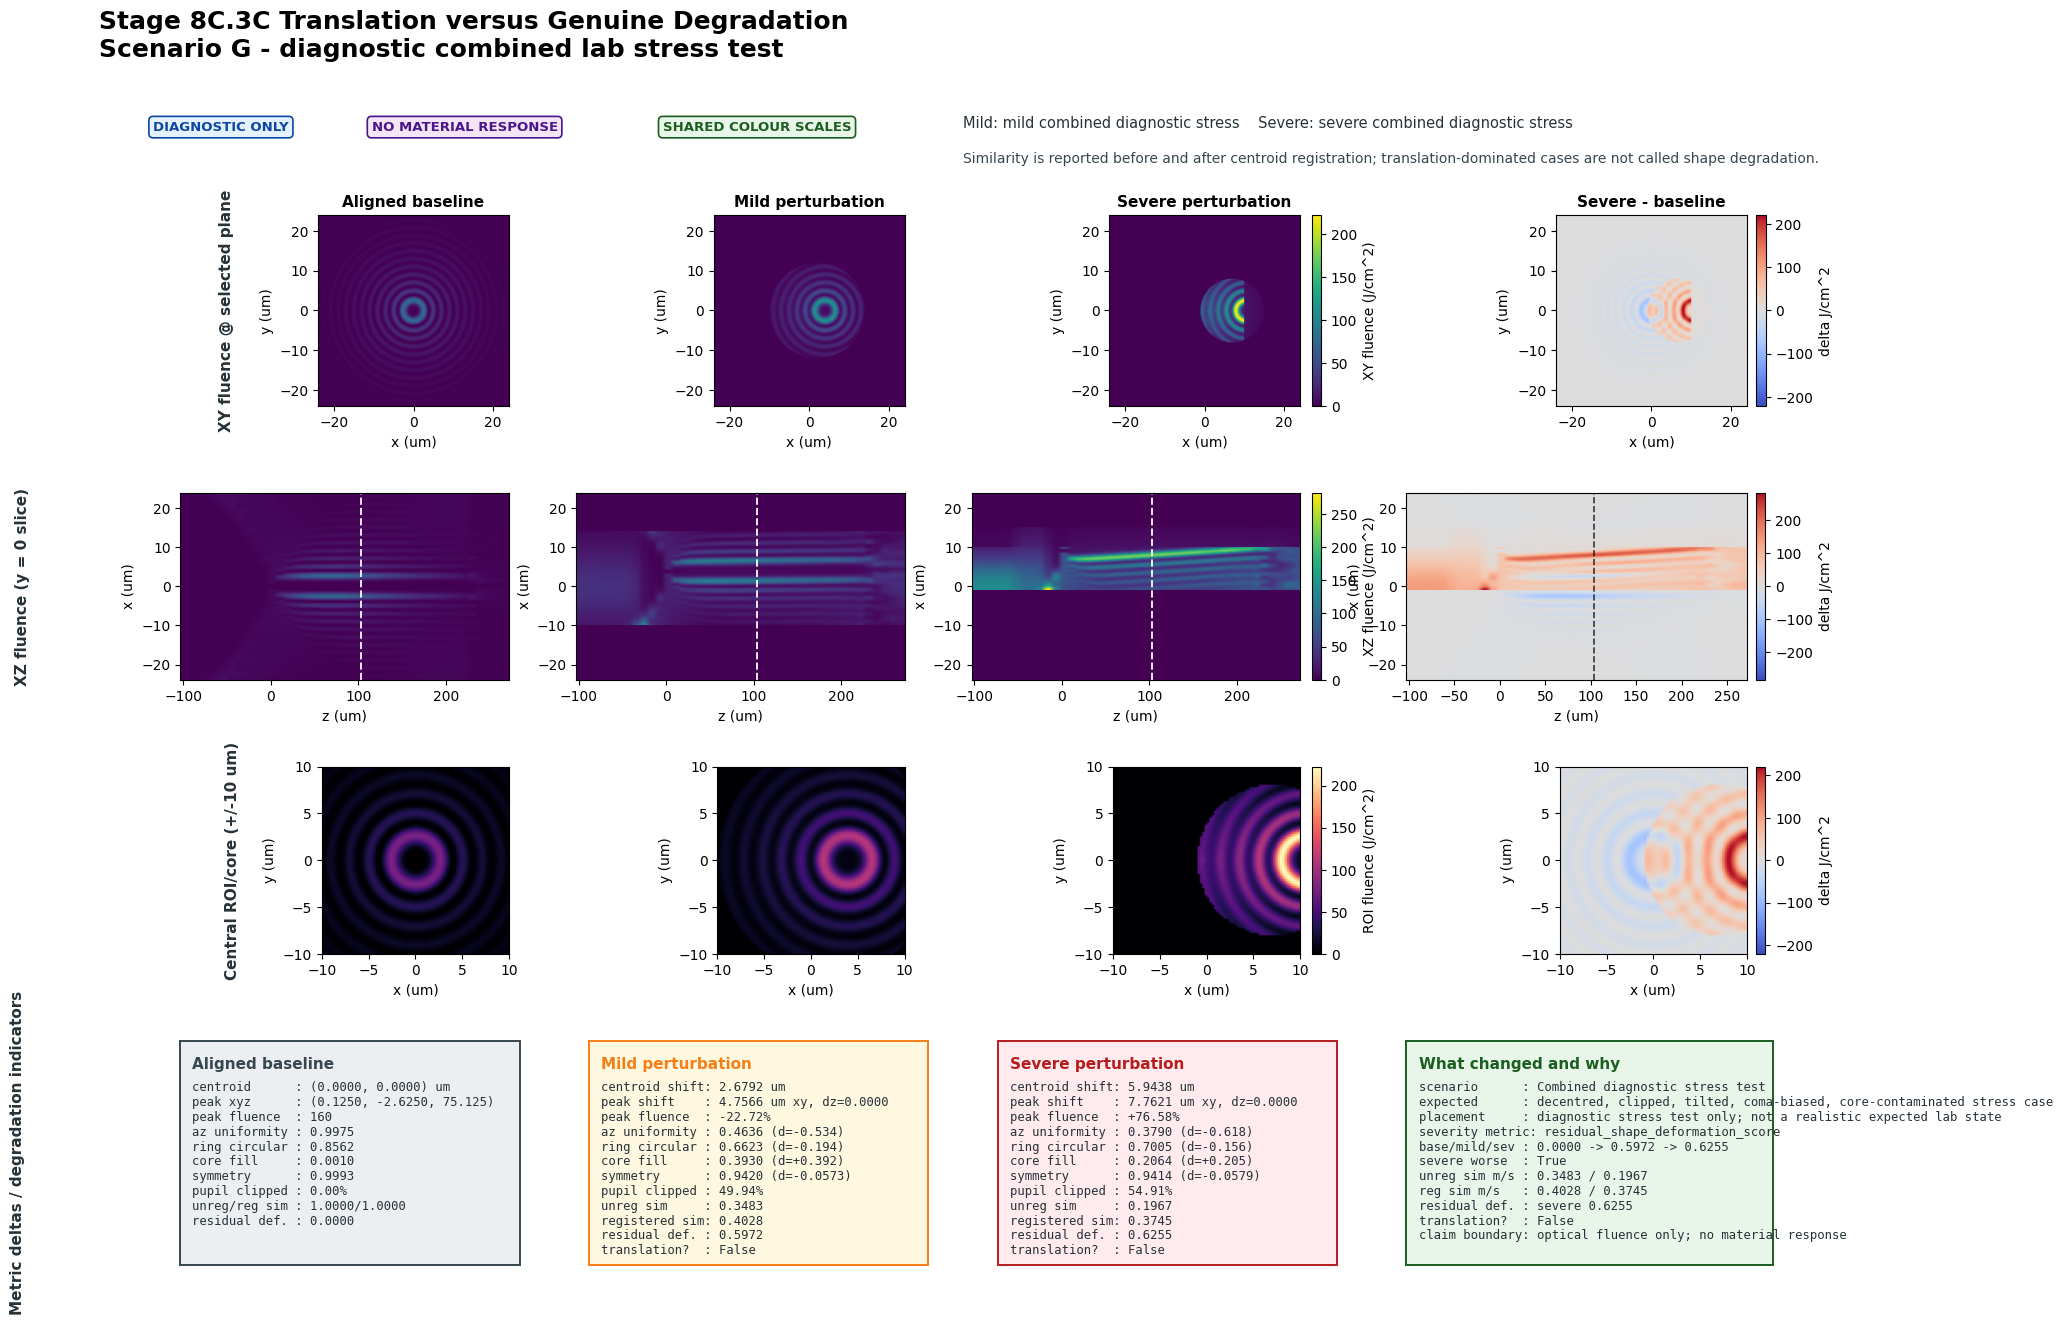

Saved Stage 8C.3C diagnostic preview (final_export_allowed=False) to:
C:\PhD\Code\Publication_Study\outputs\figures\digital_twin\stage8c3c_genuine_degradation_sweep_preview.png
Scenario severity metric: residual_shape_deformation_score
baseline -> mild -> severe: 0.0 0.5971975578492608 0.6254750095028145
severe unregistered/registered similarity: 0.19670172259636765 0.37452499049718546
translation_dominated_boolean: False


,scenario,mild,severe,metric,baseline,mild_value,severe_value,severe_worse_than_mild,unregistered_similarity_score,registered_similarity_score,centroid_shift_um,translation_dominated_boolean,residual_shape_deformation_score,counts_as_genuine_degradation
0,Scenario A - relative vortex/axicon misregistr...,vortex x=3 um; axicon fixed,vortex x=8 um; axicon fixed,residual_shape_deformation_score,0.000000,0.261048,0.562190,True,0.514921,0.437810,1.915302e+00,False,0.562190,True
1,"Scenario A-reverse - axicon shifted, vortex fixed",axicon x=3 um; vortex fixed,axicon x=8 um; vortex fixed,residual_shape_deformation_score,0.000000,0.269239,0.590642,True,0.525591,0.409358,4.665053e-01,False,0.590642,True
2,Scenario B - input beam decentre + finite SLM ...,beam decentre=0.15R; finite SLM aperture,beam decentre=0.40R; tighter SLM aperture,residual_shape_deformation_score,0.000000,0.608152,0.721141,True,0.202177,0.278859,3.953653e+00,False,0.721141,True
3,Scenario C - beam tilt + finite pupil,tilt x=2 mrad; finite pupil,tilt x=16 mrad; finite pupil,residual_shape_deformation_score,0.000000,0.223332,0.423053,True,0.578105,0.576947,2.319981e-02,False,0.423053,True
4,Scenario D - objective pupil decentre and clip...,pupil decentre=0.10R; moderate clipping,pupil decentre=0.35R; strong clipping,pupil_clipped_power_fraction,0.000000,0.559417,0.794884,True,0.426998,0.324227,4.540637e+00,False,0.675773,True
5,Scenario E - low-order aberrations,coma/astig/defocus/spherical=0.10 waves,"coma 0.80, astig 0.60, defocus/spherical 0.70 ...",residual_shape_deformation_score,0.000000,0.087369,0.502662,True,0.751997,0.497338,7.646570e-01,False,0.502662,True
6,Scenario F - zero-order leakage,zero-order leakage=0.02,zero-order leakage=0.18,core_fill_fraction,0.000975,0.020946,0.182035,True,0.805617,0.805617,5.246800e-16,False,0.194383,True
7,Scenario G - diagnostic combined lab stress test,mild combined diagnostic stress,severe combined diagnostic stress,residual_shape_deformation_score,0.000000,0.597198,0.625475,True,0.196702,0.374525,5.943805e+00,False,0.625475,True
8,Translation diagnostic - co-shifted vortex and...,vortex x=3 um; axicon x=3 um,vortex x=8 um; axicon x=8 um,centroid_shift_um,0.000000,0.578015,1.502953,True,0.382607,0.922941,1.502953e+00,True,0.077059,False


In [14]:
stage8c3c_controls_for_audit = {
    "enable_beam_tilt": True,
    "beam_tilt_x_mrad": 16.0,
    "enable_beam_decentre": True,
    "beam_decentre_x_um": 9.6,
    "enable_vortex_centre_offset": True,
    "vortex_centre_offset_x_um": 8.0,
    "enable_axicon_centre_offset": True,
    "axicon_centre_offset_x_um": 0.0,
    "enable_slm_active_area": True,
    "slm_active_width_um": 20.0,
    "slm_active_height_um": 20.0,
    "enable_first_order_filter_decentre": True,
    "first_order_filter_decentre_x_px": 5.0,
    "enable_pupil_clipping": True,
    "pupil_radius_um": 8.0,
    "pupil_decentre_x_um": 7.0,
    "enable_zernike_aberrations": True,
    "zernike_coma_x_waves": 0.60,
    "zernike_astig_0_waves": 0.60,
    "zernike_defocus_waves": 0.70,
    "zernike_spherical_waves": 0.70,
    "enable_zero_order_leakage": True,
    "zero_order_leakage_fraction": 0.10,
    "enable_sample_tilt": False,
}
placement_audit_rows = physical_placement_rows_for_controls(
    stage8c3c_controls_for_audit,
    only=stage8c3c_controls_for_audit.keys(),
)
try:
    import pandas as pd
    display(pd.DataFrame(placement_audit_rows))
except Exception:
    display(placement_audit_rows)

sensitivity_output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c3c_genuine_degradation_sweep_preview.png"
sensitivity_fig = plot_misalignment_sensitivity_sweep(
    stack,
    ledger.energy_at_sample_uJ,
    baseline_fluence=fluence_stack,
    scenario="combined_lab_stress",
    selected_plane_index=diagnostics["selected_plane_index"],
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    output_path=sensitivity_output_path if show_caveats else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
    title="Stage 8C.3C Translation versus Genuine Degradation",
)
display(sensitivity_fig)
plt.show()
plt.close(sensitivity_fig)

sensitivity_sweep_result = sensitivity_fig.stage8c3_sensitivity_result
print("Saved Stage 8C.3C diagnostic preview (final_export_allowed=False) to:")
print(sensitivity_output_path)
print("Scenario severity metric:", sensitivity_sweep_result.scenario.degradation_metric)
print(
    "baseline -> mild -> severe:",
    sensitivity_sweep_result.baseline_metrics[sensitivity_sweep_result.scenario.degradation_metric],
    sensitivity_sweep_result.mild_metrics[sensitivity_sweep_result.scenario.degradation_metric],
    sensitivity_sweep_result.severe_metrics[sensitivity_sweep_result.scenario.degradation_metric],
)
print(
    "severe unregistered/registered similarity:",
    sensitivity_sweep_result.severe_metrics["unregistered_similarity_score"],
    sensitivity_sweep_result.severe_metrics["registered_similarity_score"],
)
print("translation_dominated_boolean:", sensitivity_sweep_result.severe_metrics["translation_dominated_boolean"])

sensitivity_scenario_rows = []
for scenario_key, scenario_def in build_stage8c3_sensitivity_scenarios().items():
    scenario_sweep = compute_misalignment_sensitivity_sweep(
        stack,
        ledger.energy_at_sample_uJ,
        baseline_fluence=fluence_stack,
        scenario=scenario_key,
        selected_plane_index=diagnostics["selected_plane_index"],
        target_depth_um=focus_depth_um,
        central_roi_half_width_um=central_roi_half_width_um,
    )
    metric = scenario_sweep.scenario.degradation_metric
    sensitivity_scenario_rows.append({
        "scenario": scenario_def.title,
        "mild": scenario_def.mild_label,
        "severe": scenario_def.severe_label,
        "metric": metric,
        "baseline": scenario_sweep.baseline_metrics[metric],
        "mild_value": scenario_sweep.mild_metrics[metric],
        "severe_value": scenario_sweep.severe_metrics[metric],
        "severe_worse_than_mild": scenario_sweep.metadata["severe_worse_than_mild"],
        "unregistered_similarity_score": scenario_sweep.severe_metrics["unregistered_similarity_score"],
        "registered_similarity_score": scenario_sweep.severe_metrics["registered_similarity_score"],
        "centroid_shift_um": scenario_sweep.severe_metrics["centroid_shift_um"],
        "translation_dominated_boolean": scenario_sweep.severe_metrics["translation_dominated_boolean"],
        "residual_shape_deformation_score": scenario_sweep.severe_metrics["residual_shape_deformation_score"],
        "counts_as_genuine_degradation": scenario_def.counts_as_genuine_degradation,
    })
try:
    import pandas as pd
    display(pd.DataFrame(sensitivity_scenario_rows))
except Exception:
    display(sensitivity_scenario_rows)


## 9. Exposure bookkeeping

This is exposure bookkeeping, not material response.

In [15]:
for key, value in exposure_summary.items():
    print(f"{key}: {value}")


pulse_spacing_um: 0.04
pulses_per_spot: 75.0
dose_per_unit_length_J_m: 2394.00534375
line_duration_s: 0.5
total_pulses_on_line: 12500
total_energy_on_line_uJ: 1197002.671875
overlap_fraction: 0.9866666666666667
model_status: exposure_bookkeeping
final_export_allowed: False
warnings: []


## 10. Main integrated cockpit dashboard figure

The integrated dashboard shows experiment summary, energy ledger, exposure bookkeeping, lab realism status, XY intensity, XY fluence, central ROI zoom, XZ fluence with surface/target/selected/peak markers, peak fluence by z, raw captured-power drift, warnings, caveats, and disabled future physics.

overall display-trust status: caution


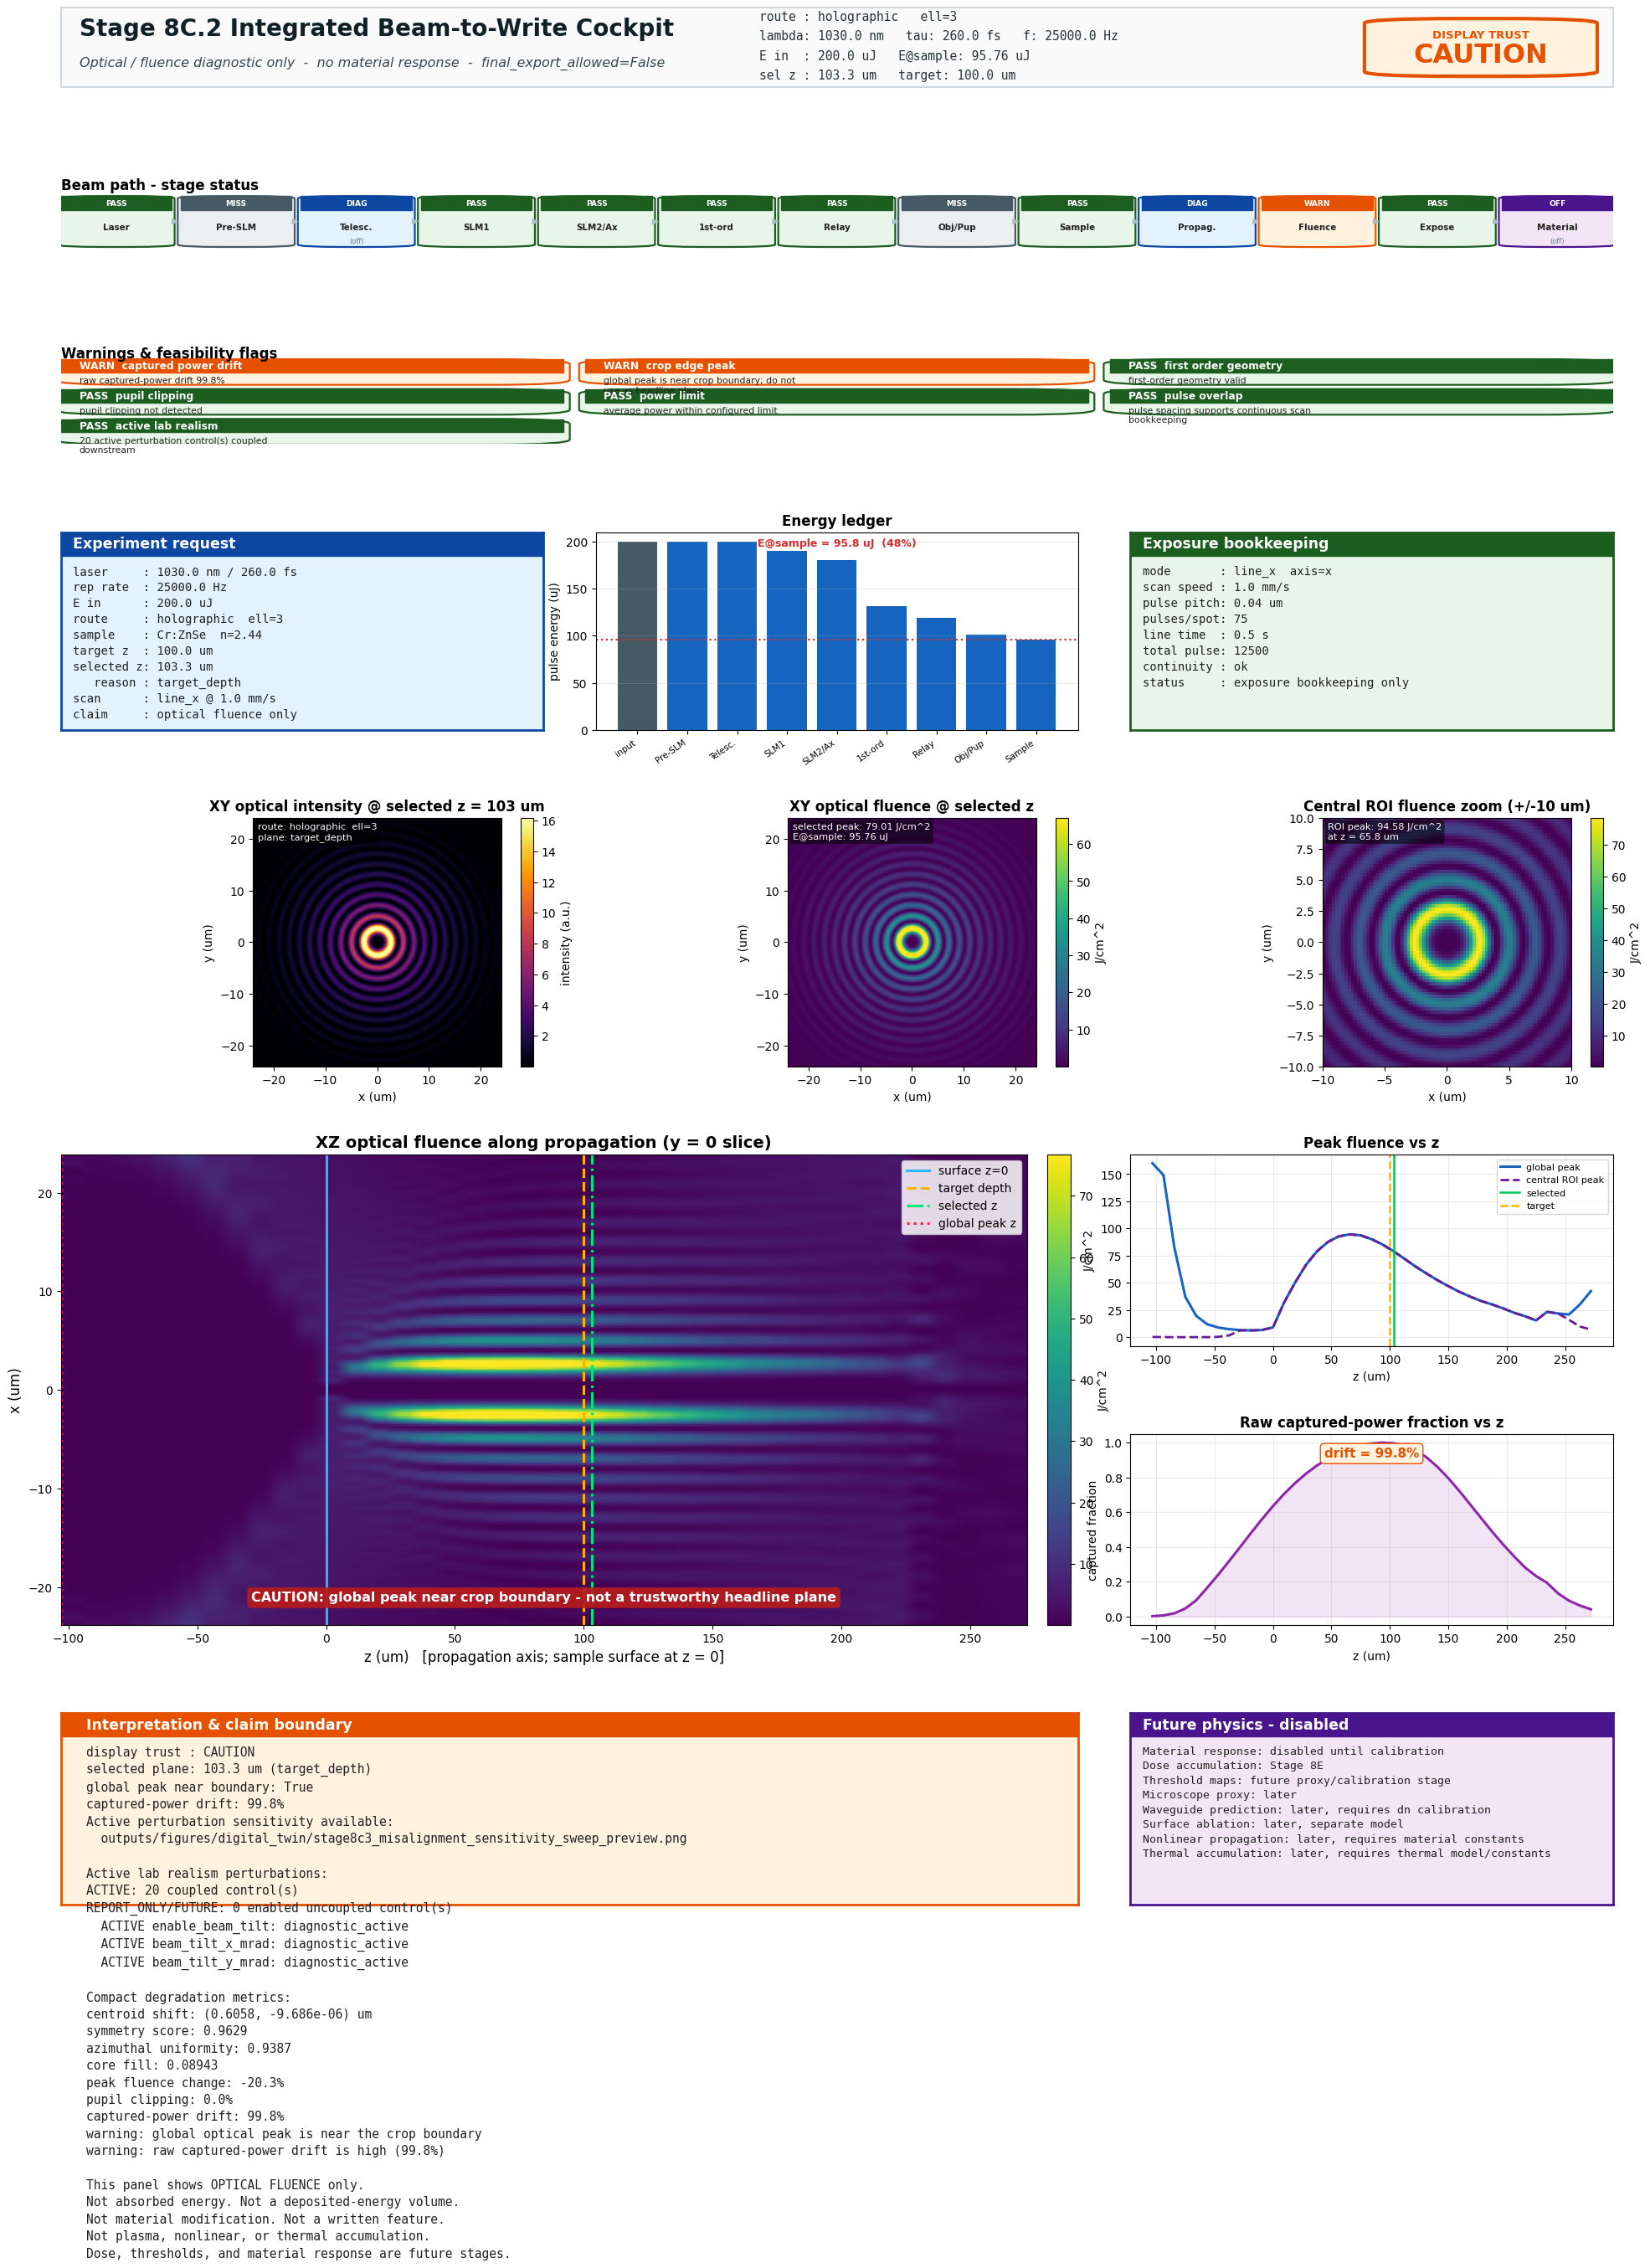

In [16]:
from IPython.display import display
import matplotlib.pyplot as plt

output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
fig = plot_integrated_cockpit_dashboard(
    stack,
    fluence_stack,
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    lab_report=lab_report,
    diagnostics=diagnostics,
    output_path=output_path if save_outputs else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
    display_scaling=display_scaling,
    display_percentile_clip=display_percentile_clip,
    perturbation_result=globals().get("perturbation_result"),
    degradation_metrics=globals().get("perturbed_degradation_metrics"),
)
print("overall display-trust status:", fig.stage8c2_metadata["overall_status"])
# Render exactly one inline copy; close before cell end to avoid a duplicate auto-render.
display(fig)
plt.close(fig)
plt.show()


## 11. Interpretation panel

In [17]:
print(make_interpretation_text(
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    diagnostics=diagnostics,
    lab_report=lab_report,
))


Energy at sample is 95.76 uJ from 200.0 uJ before optics.
Average power is below the configured limit; sample average power is 2.394 W.
The optical route is valid.
The first-order geometry is valid.
Pupil fill/clipping status is not available from current engine.
Pulse spacing is 0.04 um, giving 75 pulses per spot.
For the selected plane, peak optical fluence is 79.01 J/cm^2.
Central ROI peak is 94.58 J/cm^2.
Target-depth peak is 79.01 J/cm^2.
Peak intensity estimate is 6.154e+14 W/cm^2, assuming no nonlinear reshaping.
The global field peak is near the crop boundary.
Captured-power drift is 99.80%.
Lab realism status is caution.
This output is optical fluence only; no material modification is predicted.


## 12. Disabled future physics panels

Material response: disabled until calibration

Dose accumulation: Stage 8E

Threshold maps: future proxy/calibration stage

Microscope proxy: later

Waveguide prediction: later, requires dn calibration

Surface ablation: later, separate model

Nonlinear propagation: later, requires material constants

Thermal accumulation: later, requires thermal model/constants

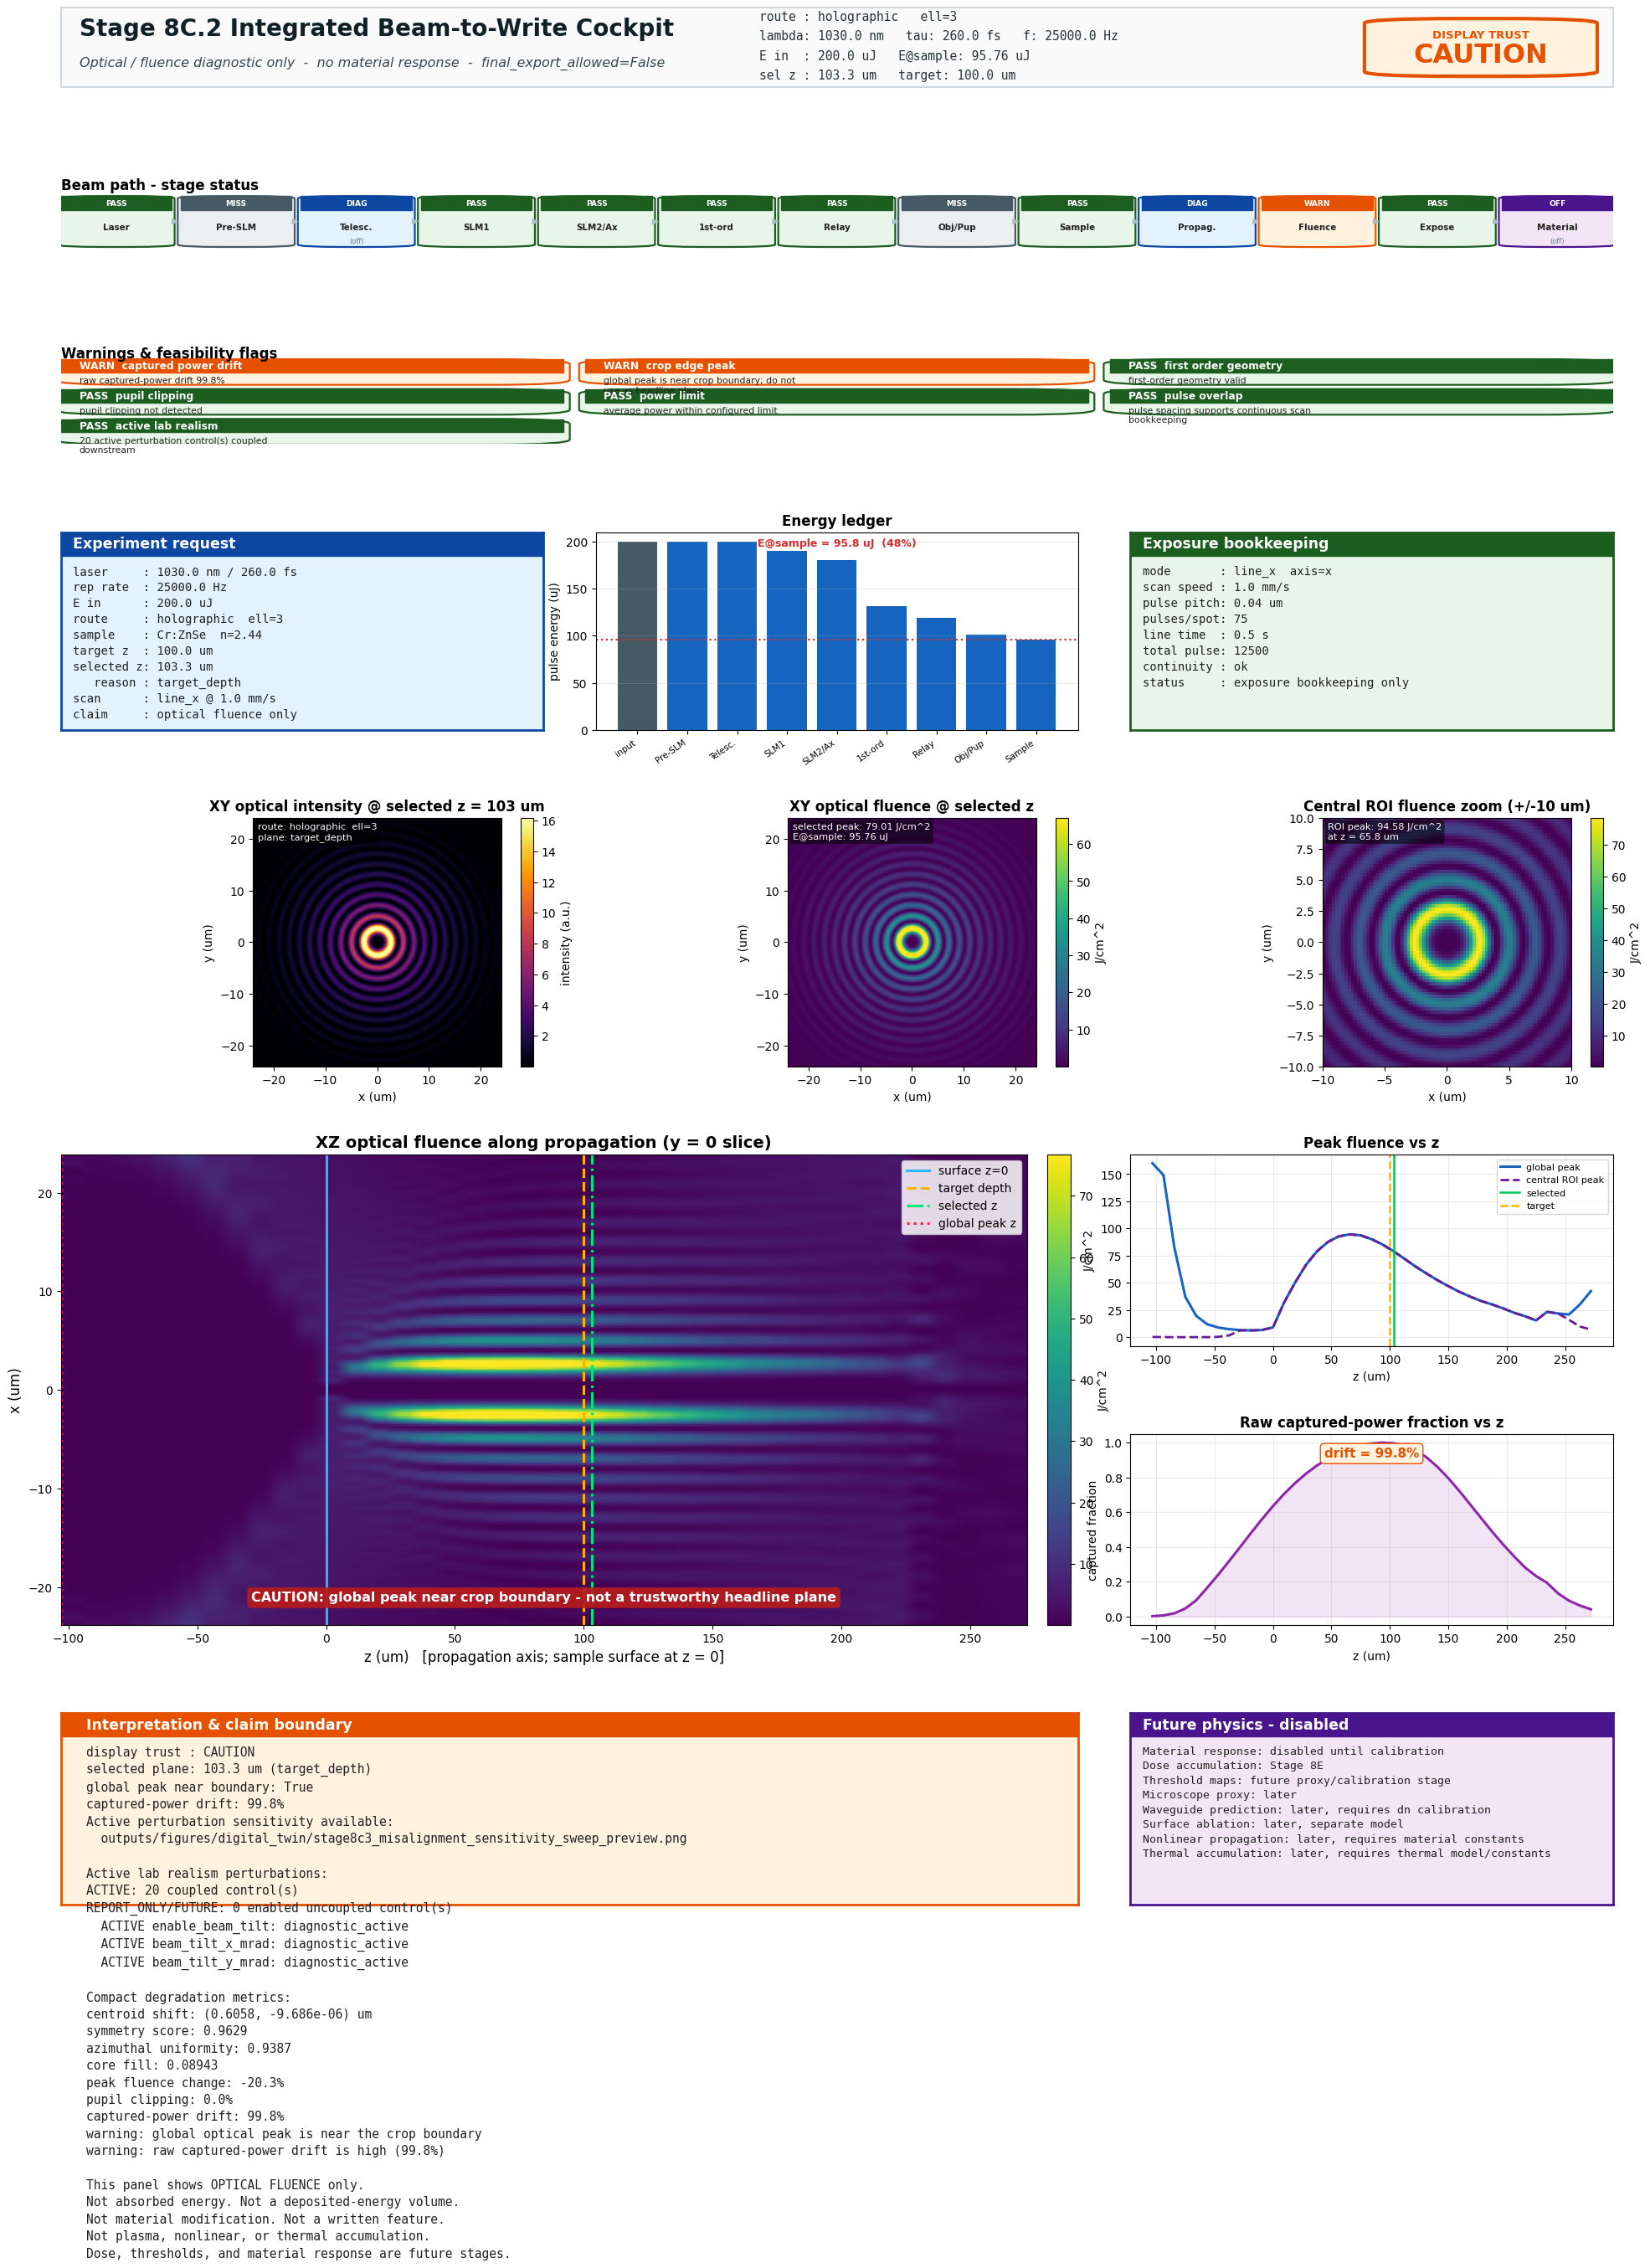

Saved diagnostic preview (final_export_allowed=False) to:
C:\PhD\Code\Publication_Study\outputs\figures\digital_twin\stage8c2_integrated_cockpit_dashboard_preview.png


In [18]:
# ============================================================
# FINAL VISUAL CHECK - confirm the dashboard rendered and save a diagnostic preview
# ============================================================
from IPython.display import display
import matplotlib.pyplot as plt

assert "fig" in globals() and fig is not None, "Cockpit dashboard figure was not created."
assert fig.stage8c2_metadata["final_export_allowed"] is False, "Dashboard must be diagnostic only."

# Show the dashboard again (single inline copy).
display(fig)
plt.show()

preview_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
# A diagnostic preview (final_export_allowed=False) is saved only with caveats on and only for a
# real/governed field - never for a unit_test_or_demo_only field.
if show_caveats and stack.source_status != "unit_test_or_demo_only":
    _saved = plot_integrated_cockpit_dashboard(
        stack, fluence_stack, controls=controls, energy_ledger=ledger,
        exposure_summary=exposure_summary, lab_report=lab_report, diagnostics=diagnostics,
        output_path=preview_path, show_caveats=show_caveats, dpi=figure_dpi,
        display_scaling=display_scaling, display_percentile_clip=display_percentile_clip,
        perturbation_result=globals().get("perturbation_result"),
        degradation_metrics=globals().get("perturbed_degradation_metrics"),
    )
    plt.close(_saved)
    print("Saved diagnostic preview (final_export_allowed=False) to:")
    print(preview_path)
else:
    print("Preview not saved (needs show_caveats=True and a real/governed field).")
